# Agent3 - 정량 분석 탐색 노트북

`main.py`(제품 코드)를 불러와서 결과를 확인하고 시각화하는 탐색용 노트북입니다.

## 실행 환경
- **로컬**: `agent3/notebooks/` 안에서 그대로 실행하면 됩니다 (기존과 동일).
- **Google Colab**: 아래 첫 코드 셀이 Colab인지 자동으로 감지해서
  1) GitHub 레포가 있으면 클론
  2) 없으면 `agent3` 폴더를 zip으로 업로드받아 압축 해제
  후 자동으로 필요한 패키지까지 설치합니다. 상황에 맞게 옵션만 골라 실행하세요.


In [1]:
import sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    if not os.path.exists('main.py'):
        from google.colab import files
        import zipfile

        print("agent3 폴더를 통째로 zip 압축한 파일을 업로드하세요 (예: agent3.zip)")
        uploaded = files.upload()
        zip_name = list(uploaded.keys())[0]
        with zipfile.ZipFile(zip_name, 'r') as z:
            z.extractall('.')

        # zip 안에 agent3/ 폴더가 그대로 들어있는 구조라면 그 안으로 이동
        if os.path.exists('agent3') and not os.path.exists('main.py'):
            os.chdir('agent3')

    # Colab 기본 이미지에 pandas/sklearn은 이미 있지만, 혹시 몰라 한번 더 설치
    !pip install -q -r requirements.txt

    project_root = '.'  # agent3 폴더 자체가 현재 위치
else:
    project_root = os.path.abspath('..')  # 로컬: notebooks/ -> agent3/

sys.path.append(project_root)
os.chdir(project_root)  # data/, outputs/ 등 상대경로가 agent3/ 기준으로 맞춰지도록

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['axes.unicode_minus'] = False

from data.dummy_data import generate_countries, OPPORTUNITY_FIELDS
from main import Agent3Analyzer, analyze

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)


agent3 폴더를 통째로 zip 압축한 파일을 업로드하세요 (예: agent3.zip)


Saving agent3_branch (1).zip to agent3_branch (1) (2).zip


## 1. 데이터 로드 & Agent3 실행

In [2]:
raw = generate_countries()
agent3 = Agent3Analyzer(raw)
out = agent3.run_all()
list(out.keys())


['risk_score',
 'cooperation_index',
 'opportunity_score',
 'opportunity_ranking',
 'feature_matrix',
 'similarity_matrix',
 'cluster',
 'pca_coords']

## 2. 위험도 점수

In [3]:
risk = out['risk_score'].sort_values(ascending=False)
risk


,risk_score
country,
캄보디아,73.47
가나,71.20
몽골,59.39
케냐,59.03
필리핀,56.69
베트남,48.87
미얀마,48.61
방글라데시,46.79
탄자니아,44.86


한글 폰트 깨짐 해결

In [6]:
# 1. 나눔 폰트 다운로드
!apt-get install -y fonts-nanum

# 2. 폰트 경로를 직접 지정하는 방식 (가장 확실함)
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 설치된 나눔바른고딕 폰트의 물리적 경로를 직접 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)

# matplotlib의 기본 폰트 패밀리 자체를 나눔바른고딕으로 강제 지정
plt.rc('font', family='NanumBarunGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("폰트 설정 완료! 아래 테스트 그래프를 확인해보세요.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 78 not upgraded.
폰트 설정 완료! 아래 테스트 그래프를 확인해보세요.


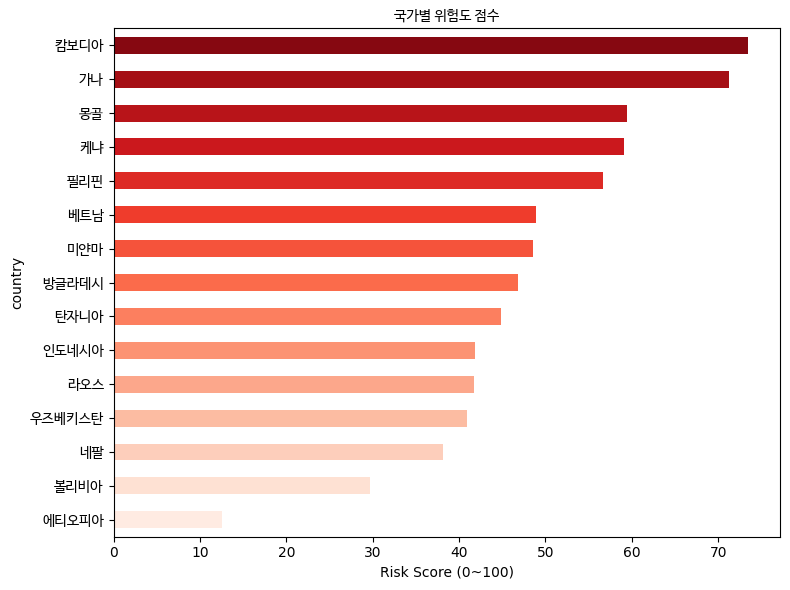

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
risk.plot(kind='barh', ax=ax, color=sns.color_palette('Reds_r', len(risk)))
ax.set_yticklabels(risk.index, fontproperties=font_prop)
ax.set_xlabel('Risk Score (0~100)')
ax.set_title('국가별 위험도 점수', fontproperties=font_prop)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 3. Cooperation Index (5단계)

In [12]:
coop = out['cooperation_index'].sort_values('score', ascending=False)
coop


,score,grade
country,,
네팔,84.29,5
방글라데시,71.81,5
볼리비아,57.71,5
미얀마,56.01,4
가나,55.65,4
탄자니아,55.38,4
필리핀,52.13,3
라오스,51.80,3
캄보디아,51.11,3


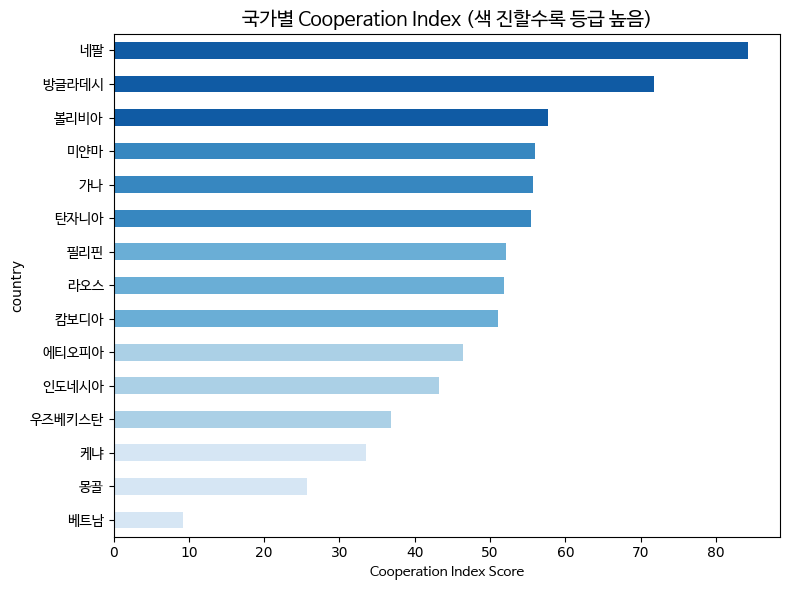

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = sns.color_palette('Blues', 5)
bar_colors = [colors[g-1] for g in coop['grade']]

coop['score'].plot(kind='barh', ax=ax, color=bar_colors)

ax.set_yticklabels(coop.index, fontproperties=font_prop)

ax.set_xlabel('Cooperation Index Score', fontproperties=font_prop)
ax.set_title('국가별 Cooperation Index (색 진할수록 등급 높음)', fontproperties=font_prop, fontsize=14)

ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Cooperation Opportunity Score - 분야별 히트맵

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54044 (\N{HANGUL SYLLABLE PAM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47308 (\N{HANGUL SYLLABLE RYO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/l

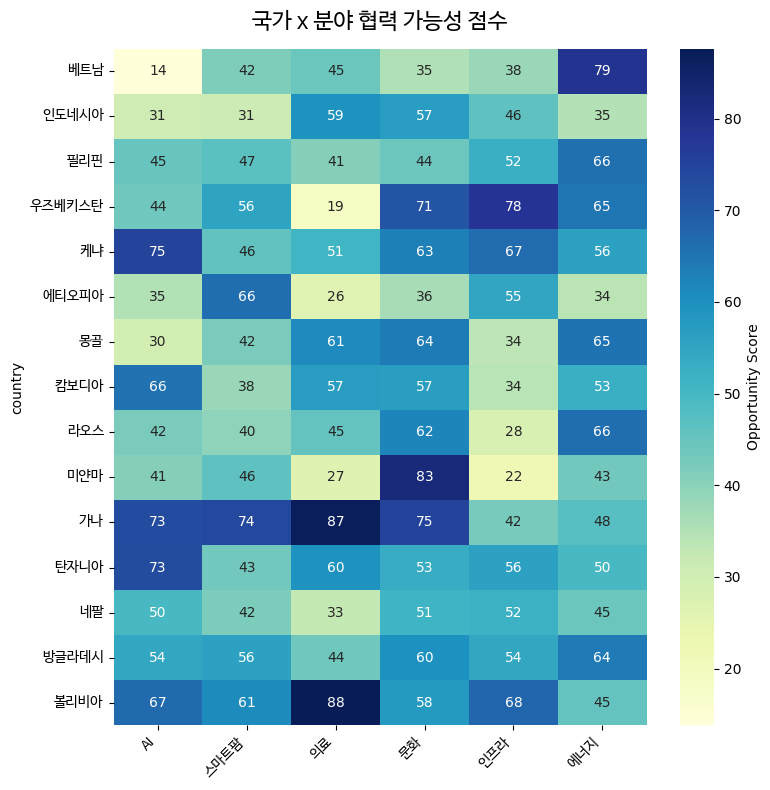

In [16]:
opp = out['opportunity_score']
fig, ax = plt.subplots(figsize=(8, 8))

sns.heatmap(opp, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax, cbar_kws={'label': 'Opportunity Score'})

ax.set_xticklabels(opp.columns, fontproperties=font_prop, rotation=45, ha='right')
ax.set_yticklabels(opp.index, fontproperties=font_prop, rotation=0)

ax.set_title('국가 x 분야 협력 가능성 점수', fontproperties=font_prop, fontsize=16, pad=15)

plt.tight_layout()
plt.show()

In [17]:
top_field_per_country = opp.idxmax(axis=1)
top_field_per_country.value_counts()


,count
에너지,5
의료,3
AI,3
인프라,2
스마트팜,1
문화,1


## 5. KMeans 군집 결과 (PCA 2D 산점도)

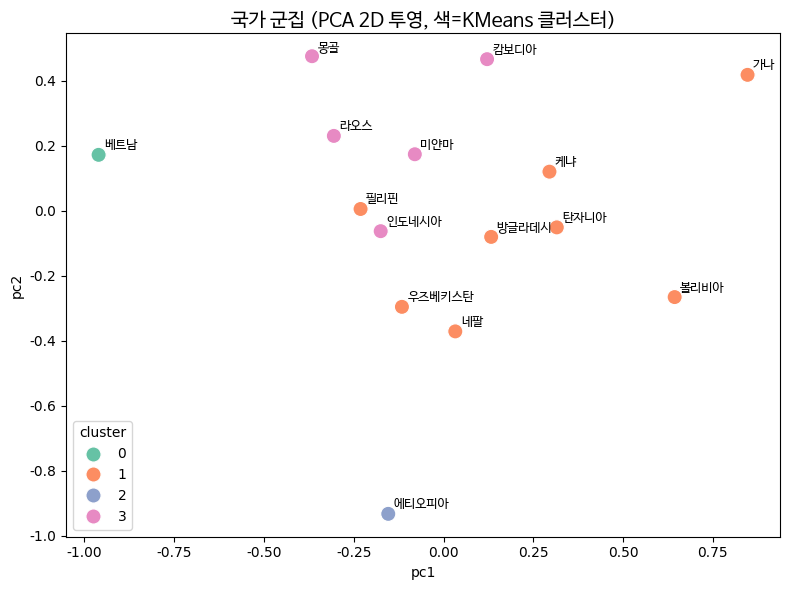

In [18]:
plot_df = out['pca_coords'].copy()
plot_df['cluster'] = out['cluster']
plot_df['risk'] = out['risk_score']

fig, ax = plt.subplots(figsize=(8, 6))

# 1. 산점도 그리기
sns.scatterplot(data=plot_df, x='pc1', y='pc2', hue='cluster', palette='Set2', s=120, ax=ax)

# 2. 각 점 옆에 국가 이름(한글) 쓰기
for country, row in plot_df.iterrows():
    ax.annotate(country, (row['pc1'], row['pc2']),
                fontproperties=font_prop, # 한글 폰트 적용
                fontsize=9,
                xytext=(4, 4),
                textcoords='offset points')

ax.set_title('국가 군집 (PCA 2D 투영, 색=KMeans 클러스터)', fontproperties=font_prop, fontsize=14)

plt.tight_layout()
plt.show()

## 6. 유사국가 추천

In [19]:
target = '베트남'  # 원하는 국가로 바꿔서 실행하면 됨
sims = agent3.recommend_similar(out['similarity_matrix'], target, top_n=5)
sims


,베트남
country,
몽골,0.825066
필리핀,0.798747
라오스,0.714230
방글라데시,0.658503
우즈베키스탄,0.635381


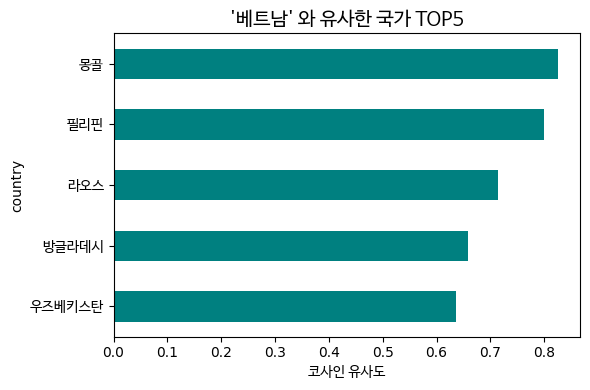

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))

sims.plot(kind='barh', ax=ax, color='teal')
ax.set_yticklabels(sims.index, fontproperties=font_prop)

ax.set_xlabel('코사인 유사도', fontproperties=font_prop)
ax.set_title(f"'{target}' 와 유사한 국가 TOP{len(sims)}", fontproperties=font_prop, fontsize=14)

ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. 전체 유사도 히트맵 (모든 국가 조합)

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48288 (\N{HANGUL SYLLABLE BE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45348 (\N{HANGUL SYLLABLE NE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/loc

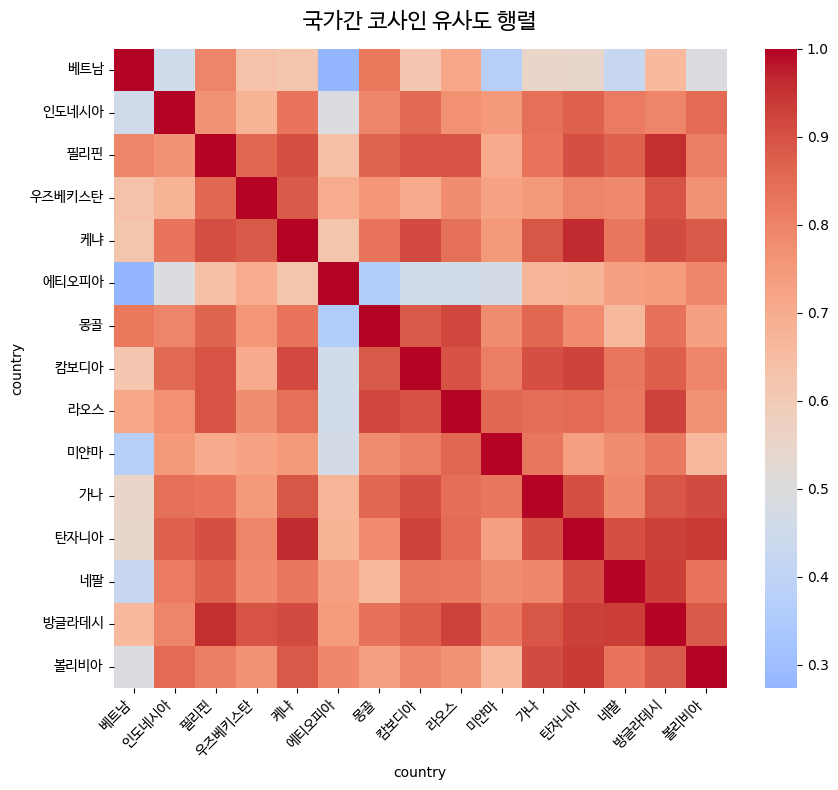

In [21]:
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(out['similarity_matrix'], cmap='coolwarm', center=0.5, annot=False, ax=ax)

ax.set_xticklabels(out['similarity_matrix'].columns, fontproperties=font_prop, rotation=45, ha='right')
ax.set_yticklabels(out['similarity_matrix'].index, fontproperties=font_prop, rotation=0)

ax.set_title('국가간 코사인 유사도 행렬', fontproperties=font_prop, fontsize=16, pad=15)

plt.tight_layout()
plt.show()